In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing  import StandardScaler

file = r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Clustering (Customer Segmentation & Persona Profiling)\.gitignore\data\processed\rfm_summary.csv"
rfm = pd.read_csv(file)

<h3>📐 ¿Por qué transformar las métricas RFM?</h3>
Las métricas de <b>Frecuencia</b> y <b>Valor Monetario</b> suelen presentar una distribución <b>asimétrica hacia la derecha</b> (<i>right-skewed</i>): la gran mayoría de clientes realiza pocas compras de bajo monto, mientras que unos pocos clientes representan valores masivos (<i>outliers</i>).

Al aplicar una transformación logarítmica ($\log(x)$) y un escalado estándar ($Z$-score) logramos:

1. Normalizar la distribución (hacerla más simétrica y similar a una curva Gaussiana).

2. Evitar que las variables con números muy altos (como el dinero) dominen sobre variables de menor escala (como la recencia) en el cálculo de distancias euclidianas.

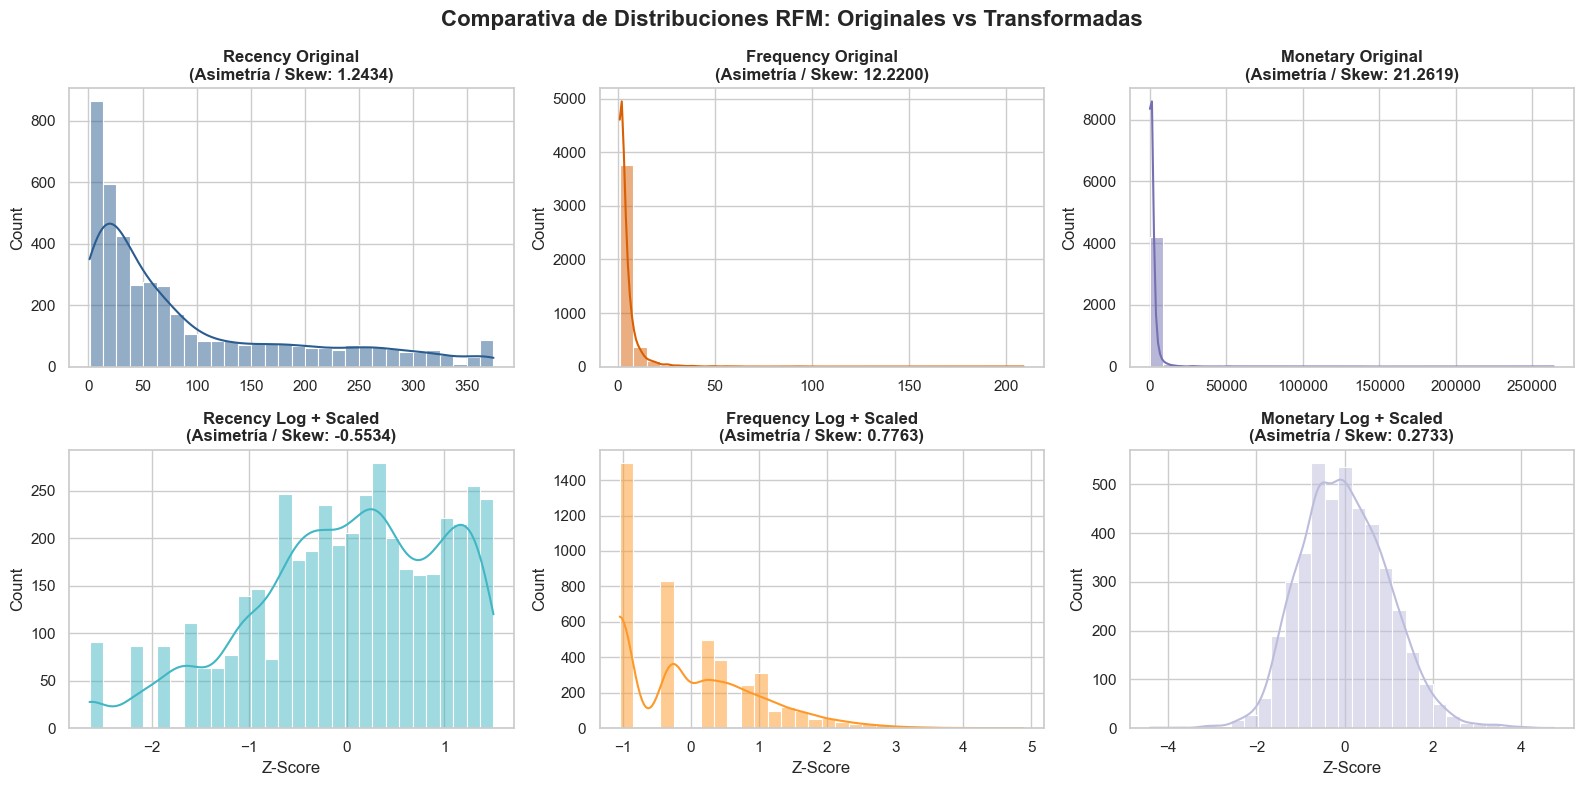

In [3]:
""" Estilo visual limpio para gráficos """
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

""" Aplicamos transformación logarítmica """
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].apply(np.log)

""" Aplicamos un Escalador """
scaler = StandardScaler()
rfm_scaled = pd.DataFrame(scaler.fit_transform(rfm_log), columns=["Recency", "Frequency", "Monetary"])

""" Creamos el gráfico de distribución sin transformación y escalador (Fila 1) """
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16,8))
features = ["Recency", "Frequency", "Monetary"]
colors_orig = ["#2b5c8f", "#d95f02", "#7570b3"]
colors_trans = ["#41b6c4", "#fe9929", "#bcbddc"]

for i, col in enumerate(features):
    sns.histplot(data=rfm[col], kde=True, ax=axes[0,i], color=colors_orig[i], bins=30)
    skewness = rfm[col].skew()
    axes[0, i].set_title(f"{col} Original\n(Asimetría / Skew: {skewness:,.4f})", fontsize=12, fontweight="bold")
    axes[0, i].set_xlabel("")

""" Creaos el gráfico de distribución con transformación y escalador (Fila 2)"""
for i, col in enumerate(features):
    sns.histplot(data=rfm_scaled[col], kde=True, ax=axes[1, i], color=colors_trans[i], bins=30)
    skewness_trans = rfm_scaled[col].skew()
    axes[1, i].set_title(f"{col} Log + Scaled\n(Asimetría / Skew: {skewness_trans:,.4f})", fontsize=12, fontweight="bold")
    axes[1, i].set_xlabel("Z-Score")

plt.suptitle("Comparativa de Distribuciones RFM: Originales vs Transformadas", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
rfm_scaled["CustomerID"] = rfm["CustomerID"]
rfm_scaled.to_csv(r"C:\Users\Highlightning\Documents\Ciencia de Datos\Proyectos\Clustering (Customer Segmentation & Persona Profiling)\.gitignore\data\processed\rfm_scaled.csv", index=False)
print("¡Data transformada y escalada, y guardada exitosamente en data/processed/rfm_scaled.csv!")

¡Data transformada y escalada, y guardada exitosamente en data/processed/rfm_scaled.csv!
